# Import de dados

Esse estudo tem por objetiv auxiliar na resposta das perguntas:<br>
1, 5 e 10

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [54]:
df_2024 = pd.read_excel('BASE DE DADOS PEDE 2024 - DATATHON.xlsx', sheet_name='PEDE2024')
df_2023 = pd.read_excel('BASE DE DADOS PEDE 2024 - DATATHON.xlsx', sheet_name='PEDE2023')
df_2022 = pd.read_excel('BASE DE DADOS PEDE 2024 - DATATHON.xlsx', sheet_name='PEDE2022')

In [55]:
# Definindo colunas padrão
COLUNAS_PADRAO = {
    # Identificação
    'RA',
    'NOME',
    'ANO',
    'FASE',
    'FASE_IDEAL',
    'DEFASAGEM',
    'IAN',
    'IDA',
    'NOTA_MAT',
    'NOTA_PORT',
    'NOTA_ING',
    'IEG',
    'IPS',
    'IPP',
    'ANO_INGRESSO',
    'INSTITUICAO_ENSINO',
    'GENERO',
    'IDADE'
}

In [56]:
MAP_2022 = {
    'RA': 'RA',
    'Nome': 'NOME',
    'Fase': 'FASE',
    'Fase ideal': 'FASE_IDEAL',
    'Defas': 'DEFASAGEM',
    'IAN': 'IAN',
    'IDA': 'IDA',
    'Matem': 'NOTA_MAT',
    'Portug': 'NOTA_PORT',
    'Inglês': 'NOTA_ING',
    'IEG': 'IEG',
    'IPS': 'IPS',
    'IAA': 'IAA', 
    'Ano ingresso': 'ANO_INGRESSO',
    'Instituição de ensino': 'INSTITUICAO_ENSINO',
    'Gênero': 'GENERO',
    'Idade 22': 'IDADE'
}

MAP_2023 = {
    'RA': 'RA',
    'Nome Anonimizado': 'NOME',
    'Fase': 'FASE',
    'Fase Ideal': 'FASE_IDEAL',
    'Defasagem': 'DEFASAGEM',
    'IAN': 'IAN',
    'IDA': 'IDA',
    'Mat': 'NOTA_MAT',
    'Por': 'NOTA_PORT',
    'Ing': 'NOTA_ING',
    'IEG': 'IEG',
    'IPS': 'IPS',
    'IPP': 'IPP',
    'Ano ingresso': 'ANO_INGRESSO',
    'Instituição de ensino': 'INSTITUICAO_ENSINO',
    'Gênero': 'GENERO',
    'Idade': 'IDADE'
}

MAP_2024 = {
    'RA': 'RA',
    'Nome Anonimizado': 'NOME',
    'Fase': 'FASE',
    'Fase Ideal': 'FASE_IDEAL',
    'Defasagem': 'DEFASAGEM',
    'IAN': 'IAN',
    'IDA': 'IDA',
    'Mat': 'NOTA_MAT',
    'Por': 'NOTA_PORT',
    'Ing': 'NOTA_ING',
    'IEG': 'IEG',
    'IPS': 'IPS',
    'IPP': 'IPP',
    'Ano ingresso': 'ANO_INGRESSO',
    'Instituição de ensino': 'INSTITUICAO_ENSINO',
    'Gênero': 'GENERO',
    'Idade': 'IDADE'
}


In [57]:
def padronizar_base(df, map_colunas, ano):
    df = df.copy()

    # Renomear colunas
    df = df.rename(columns=map_colunas)

    # Adicionar coluna de ano
    df['ANO'] = ano

    # Criar colunas que não existirem
    for col in COLUNAS_PADRAO:
        if col not in df.columns:
            df[col] = pd.NA

    # Selecionar apenas o schema final
    df = df[list(COLUNAS_PADRAO)]

    return df

df_2022_std = padronizar_base(df_2022, MAP_2022, 2022)
df_2023_std = padronizar_base(df_2023, MAP_2023, 2023)
df_2024_std = padronizar_base(df_2024, MAP_2024, 2024)


#Trazendo todos os dados para um df único modelo
df_modelo = pd.concat([df_2022_std, df_2023_std, df_2024_std])


C:\Users\gusta\AppData\Local\Temp\ipykernel_5000\2944709161.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_modelo = pd.concat([df_2022_std, df_2023_std, df_2024_std])


In [58]:
df_modelo

,NOTA_ING,RA,IDADE,IPP,ANO_INGRESSO,NOTA_PORT,IEG,DEFASAGEM,IDA,IAN,INSTITUICAO_ENSINO,IPS,FASE,NOME,NOTA_MAT,FASE_IDEAL,ANO,GENERO
0,6.0,RA-1,19,NaN,2016,3.5,4.1,-1,4.0,5.0,Escola Pública,5.6,7,Aluno-1,2.7,Fase 8 (Universitários),2022,Menina
1,9.7,RA-2,17,NaN,2017,4.5,5.2,0,6.8,10.0,Rede Decisão,6.3,7,Aluno-2,6.3,Fase 7 (3º EM),2022,Menina
2,6.9,RA-3,17,NaN,2016,4.0,7.9,0,5.6,10.0,Rede Decisão,5.6,7,Aluno-3,5.8,Fase 7 (3º EM),2022,Menina
3,8.7,RA-4,17,NaN,2017,3.5,4.5,0,5.0,10.0,Rede Decisão,5.6,7,Aluno-4,2.8,Fase 7 (3º EM),2022,Menino
4,5.7,RA-5,17,NaN,2016,2.9,8.6,0,5.2,10.0,Rede Decisão,5.6,7,Aluno-5,7.0,Fase 7 (3º EM),2022,Menina
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1151,NaN,RA-1658,21,NaN,2021,NaN,0.0,1,NaN,10.0,Privada,NaN,9,Aluno-1658,NaN,Fase 8 (Universitários),2024,Masculino
1152,NaN,RA-1659,21,NaN,2021,NaN,0.0,1,NaN,10.0,Bolsista Universitário *Formado (a),NaN,9,Aluno-1659,NaN,Fase 8 (Universitários),2024,Masculino
1153,NaN,RA-1252,22,NaN,2021,NaN,0.0,1,NaN,10.0,Privada,NaN,9,Aluno-1252,NaN,Fase 8 (Universitários),2024,Feminino
1154,NaN,RA-1660,24,NaN,2021,NaN,0.0,1,NaN,10.0,Bolsista Universitário *Formado (a),NaN,9,Aluno-1660,NaN,Fase 8 (Universitários),2024,Feminino


In [59]:
df_modelo['INSTITUICAO_ENSINO'].unique()

array(['Escola Pública', 'Rede Decisão', 'Escola JP II', 'Pública',
       'Privada', 'Privada - Programa de Apadrinhamento',
       'Privada - Programa de apadrinhamento', 'Concluiu o 3º EM',
       'Nenhuma das opções acima', 'Privada *Parcerias com Bolsa 100%',
       'Privada - Pagamento por *Empresa Parceira', nan,
       'Bolsista Universitário *Formado (a)'], dtype=object)

In [60]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3030 entries, 0 to 1155
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   NOTA_ING            1091 non-null   float64
 1   RA                  3030 non-null   object 
 2   IDADE               3030 non-null   object 
 3   IPP                 1992 non-null   float64
 4   ANO_INGRESSO        3030 non-null   int64  
 5   NOTA_PORT           2845 non-null   float64
 6   IEG                 2954 non-null   float64
 7   DEFASAGEM           3030 non-null   int64  
 8   IDA                 2852 non-null   float64
 9   IAN                 3030 non-null   float64
 10  INSTITUICAO_ENSINO  3029 non-null   object 
 11  IPS                 2859 non-null   float64
 12  FASE                3030 non-null   object 
 13  NOME                3030 non-null   object 
 14  NOTA_MAT            2846 non-null   float64
 15  FASE_IDEAL          3030 non-null   object 
 16  ANO        

In [61]:
df = df_modelo

In [62]:
# Padronizando as fases
# Observação, Fase == 9 vou entender como 9° ano, fase 4

import re
import unicodedata

# ==========================================================
# 1) Funções utilitárias
# ==========================================================
def strip_accents(s):
    if pd.isna(s):
        return ""
    s = str(s)
    s = unicodedata.normalize("NFKD", s)
    return "".join(c for c in s if not unicodedata.combining(c))


def normalize_text(x):
    s = strip_accents(x)
    s = s.upper().strip()
    s = " ".join(s.split())
    return s


# ==========================================================
# 2) Padronizar FASE
# ==========================================================
def padronizar_fase(v):

    if pd.isna(v):
        return np.nan

    s = normalize_text(v)

    # -----------------------------------------
    # Casos numéricos puros
    # -----------------------------------------
    try:
        num = int(float(s))

        mapa_num = {
            0: "ALFA",
            1: "FASE 1",
            2: "FASE 2",
            3: "FASE 3",
            4: "FASE 4",
            5: "FASE 5",
            6: "FASE 6",
            7: "FASE 7",
            8: "FASE 8",
            9: "FASE 4"   # 9º ano
        }

        if num in mapa_num:
            return mapa_num[num]

    except:
        pass

    # -----------------------------------------
    # Já vem como FASE X
    # -----------------------------------------
    if "FASE" in s:
        match = re.search(r"FASE\s*(\d)", s)

        if match:
            fase_num = int(match.group(1))
            return f"FASE {fase_num}"

    # -----------------------------------------
    # ALFA
    # -----------------------------------------
    if "ALFA" in s:
        return "ALFA"

    # -----------------------------------------
    # Turmas (1A, 2B, 5C...)
    # -----------------------------------------
    match_turma = re.match(r"^(\d+)", s)

    if match_turma:

        serie = int(match_turma.group(1))

        # 1º e 2º ano
        if serie in [1, 2]:
            return "ALFA"

        # 3º e 4º ano
        elif serie in [3, 4]:
            return "FASE 1"

        # 5º e 6º ano
        elif serie in [5, 6]:
            return "FASE 2"

        # 7º e 8º ano
        elif serie in [7, 8]:
            return "FASE 3"

        # 9º ano
        elif serie == 9:
            return "FASE 4"

    return np.nan


# ==========================================================
# 3) Padronizar FASE_IDEAL
# ==========================================================
def padronizar_fase_ideal(v):

    if pd.isna(v):
        return np.nan

    s = normalize_text(v)

    if "ALFA" in s:
        return "ALFA"

    match = re.search(r"FASE\s*(\d)", s)

    if match:
        fase_num = int(match.group(1))
        return f"FASE {fase_num}"

    return np.nan


# ==========================================================
# 4) Aplicação
# ==========================================================
df["FASE_PADRONIZADA"] = df["FASE"].apply(padronizar_fase)

df["FASE_IDEAL_PADRONIZADA"] = (
    df["FASE_IDEAL"]
    .apply(padronizar_fase_ideal)
)


# ==========================================================
# 5) Criar versão ordinal
# ==========================================================
mapa_fase_num = {
    "ALFA": 0,
    "FASE 1": 1,
    "FASE 2": 2,
    "FASE 3": 3,
    "FASE 4": 4,
    "FASE 5": 5,
    "FASE 6": 6,
    "FASE 7": 7,
    "FASE 8": 8
}

df["FASE_NUM"] = (
    df["FASE_PADRONIZADA"]
    .map(mapa_fase_num)
)

df["FASE_IDEAL_NUM"] = (
    df["FASE_IDEAL_PADRONIZADA"]
    .map(mapa_fase_num)
)

# Preparação base

In [63]:

import seaborn as sns

sns.set_style("whitegrid")


# ------------------------------------------------
# Tempo na associação
# ------------------------------------------------
df["TEMPO_ASSOCIACAO"] = (
    df["ANO"] - df["ANO_INGRESSO"]
)

# Garantir numérico
colunas_num = [
    "IAN", "IDA", "IEG",
    "IPS", "IPP",
    "TEMPO_ASSOCIACAO"
]

for c in colunas_num:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Retrato geral do IAN

count    3030.000000
mean        7.179043
std         2.535266
min         2.500000
25%         5.000000
50%         5.000000
75%        10.000000
max        10.000000
Name: IAN, dtype: float64


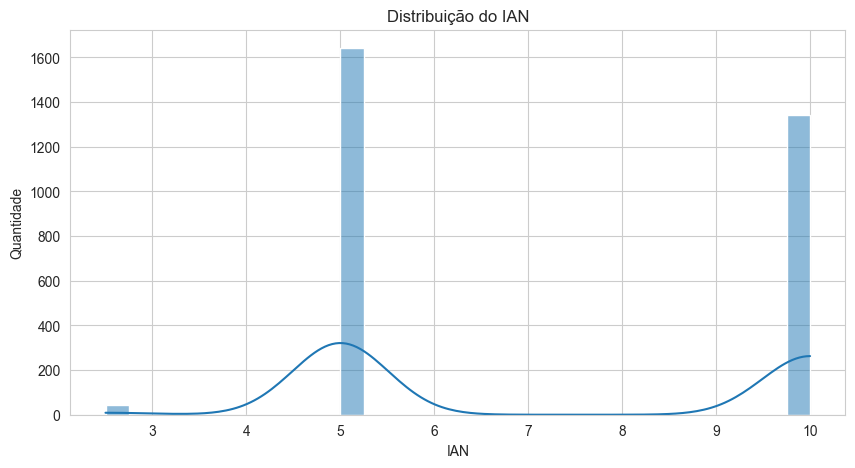

In [64]:
print(df["IAN"].describe())

plt.figure(figsize=(10,5))

sns.histplot(
    df["IAN"],
    bins=30,
    kde=True
)

plt.title("Distribuição do IAN")
plt.xlabel("IAN")
plt.ylabel("Quantidade")

plt.show()

In [65]:
# O IAN apresenta uma distribuição fortemente concentrada em dois grupos principais (≈5 e ≈10), 
# sugerindo uma população dividida entre alunos com defasagem moderada e alunos plenamente adequados ao nível esperado, com poucos casos intermediários.

# Evolução do IAN ao longo dos anos

,ANO,mean,median,count
0,2022,6.424419,5.0,860
1,2023,7.243590,5.0,1014
2,2024,7.683824,10.0,1156


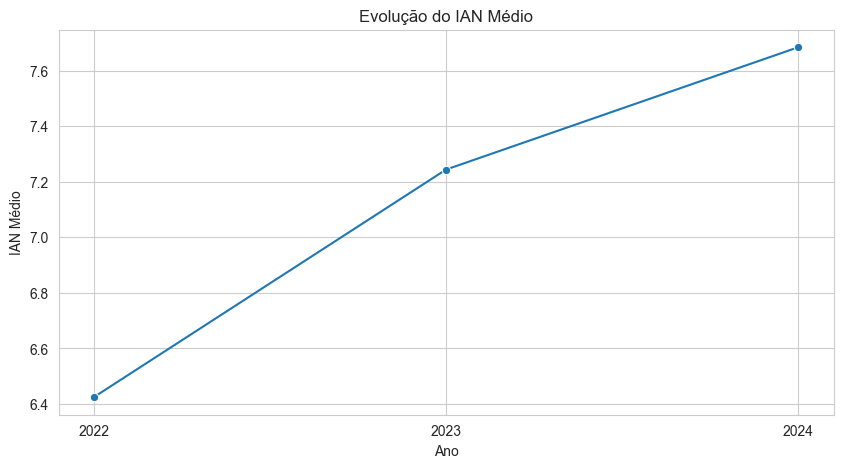

In [66]:
ian_ano = (
    df.groupby("ANO")["IAN"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

display(ian_ano)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=ian_ano,
    x="ANO",
    y="mean",
    marker="o"
)

# força anos inteiros no eixo
anos = sorted(df["ANO"].dropna().unique())

plt.xticks(anos)

plt.title("Evolução do IAN Médio")
plt.xlabel("Ano")
plt.ylabel("IAN Médio")

plt.show()

O IAN médio apresenta evolução positiva contínua entre 2022 e 2024, indicando uma melhora gradual da adequação dos alunos ao nível esperado ao longo do tempo, com ganho mais expressivo entre 2022 e 2023.


# IAN por tipo de fase

,mean,median,count
FASE_PADRONIZADA,,,
FASE 6,6.176471,5.0,51
FASE 5,6.500000,5.0,125
FASE 2,6.828125,5.0,480
FASE 1,6.986252,5.0,691
ALFA,7.031408,5.0,987
FASE 7,7.500000,7.5,44
FASE 4,7.572115,10.0,208
FASE 3,7.992126,10.0,381
FASE 8,10.000000,10.0,63


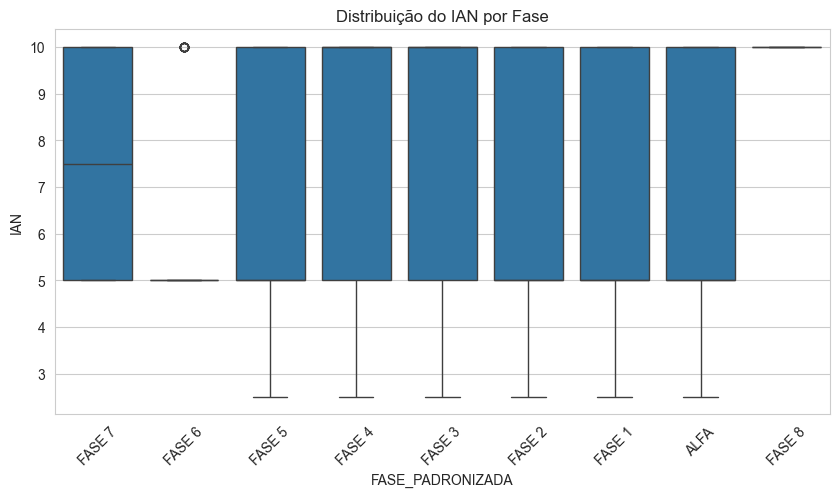

In [67]:
fase_ian = (
    df.groupby("FASE_PADRONIZADA")["IAN"]
    .agg(["mean", "median", "count"])
    .sort_values("mean")
)

display(fase_ian)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="FASE_PADRONIZADA",
    y="IAN"
)

plt.title("Distribuição do IAN por Fase")
plt.xticks(rotation=45)

plt.show()

A maior parte das fases apresenta concentração do IAN entre 5 e 10, sugerindo coexistência de alunos adequados e com defasagem em praticamente toda a jornada educacional. Já a Fase 8 (universitários) apresenta desempenho consistentemente alto (IAN ≈ 10), indicando adequação plena ao nível esperado.

# IAN por tipo de ensino

In [68]:
df

,NOTA_ING,RA,IDADE,IPP,ANO_INGRESSO,NOTA_PORT,IEG,DEFASAGEM,IDA,IAN,...,NOME,NOTA_MAT,FASE_IDEAL,ANO,GENERO,FASE_PADRONIZADA,FASE_IDEAL_PADRONIZADA,FASE_NUM,FASE_IDEAL_NUM,TEMPO_ASSOCIACAO
0,6.0,RA-1,19,NaN,2016,3.5,4.1,-1,4.0,5.0,...,Aluno-1,2.7,Fase 8 (Universitários),2022,Menina,FASE 7,FASE 8,7,8,6
1,9.7,RA-2,17,NaN,2017,4.5,5.2,0,6.8,10.0,...,Aluno-2,6.3,Fase 7 (3º EM),2022,Menina,FASE 7,FASE 7,7,7,5
2,6.9,RA-3,17,NaN,2016,4.0,7.9,0,5.6,10.0,...,Aluno-3,5.8,Fase 7 (3º EM),2022,Menina,FASE 7,FASE 7,7,7,6
3,8.7,RA-4,17,NaN,2017,3.5,4.5,0,5.0,10.0,...,Aluno-4,2.8,Fase 7 (3º EM),2022,Menino,FASE 7,FASE 7,7,7,5
4,5.7,RA-5,17,NaN,2016,2.9,8.6,0,5.2,10.0,...,Aluno-5,7.0,Fase 7 (3º EM),2022,Menina,FASE 7,FASE 7,7,7,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1151,NaN,RA-1658,21,NaN,2021,NaN,0.0,1,NaN,10.0,...,Aluno-1658,NaN,Fase 8 (Universitários),2024,Masculino,FASE 4,FASE 8,4,8,3
1152,NaN,RA-1659,21,NaN,2021,NaN,0.0,1,NaN,10.0,...,Aluno-1659,NaN,Fase 8 (Universitários),2024,Masculino,FASE 4,FASE 8,4,8,3
1153,NaN,RA-1252,22,NaN,2021,NaN,0.0,1,NaN,10.0,...,Aluno-1252,NaN,Fase 8 (Universitários),2024,Feminino,FASE 4,FASE 8,4,8,3
1154,NaN,RA-1660,24,NaN,2021,NaN,0.0,1,NaN,10.0,...,Aluno-1660,NaN,Fase 8 (Universitários),2024,Feminino,FASE 4,FASE 8,4,8,3


In [ ]:

# ===========================================================
# 1) Funções utilitárias de padronização de texto
# ============================================================
def _strip_accents(s: str) -> str:
    """Remove acentos e normaliza string para facilitar regras."""
    if s is None:
        return ""
    s = str(s)
    s = unicodedata.normalize("NFKD", s)
    return "".join([c for c in s if not unicodedata.combining(c)])

def norm_txt(x) -> str:
    """Normaliza: lower, sem acento, sem espaços extras."""
    if pd.isna(x):
        return ""
    s = _strip_accents(x)
    s = s.strip().lower()
    s = " ".join(s.split())
    return s

# ============================================================
# 2) Padronizar tipo de ensino: ENSINO_GRUPO
# ============================================================
def map_ensino_grupo(v):
    s = norm_txt(v)

    if s == "":
        return "Não informado"

    # Pública
    if "publica" in s or "escola publica" in s:
        return "Pública"

    # Privada (inclui apadrinhamento, bolsa, parcerias etc.)
    if "privada" in s:
        return "Privada"

    # Redes / escolas específicas (mantidas separadas por segurança)
    if "rede decisao" in s or "escola jp ii" in s or "jp ii" in s:
        return "Rede/Específica"

    # Casos não aplicáveis / outros
    if "concluiu" in s or "nenhuma" in s or "universitario" in s or "formado" in s:
        return "Outros/Não aplicável"

    # fallback
    return "Outros/Não aplicável"

df["ENSINO_GRUPO"] = df["INSTITUICAO_ENSINO"].apply(map_ensino_grupo)

IAN_FAIXA,Adequado (10),Defasagem Alta (<5),Defasagem Moderada (5)
ENSINO_GRUPO,,,
Não informado,100.0,0.0,0.0
Outros/Não aplicável,58.6,0.0,41.4
Privada,82.8,0.0,17.2
Pública,37.1,1.7,61.2
Rede/Específica,56.5,3.7,39.8


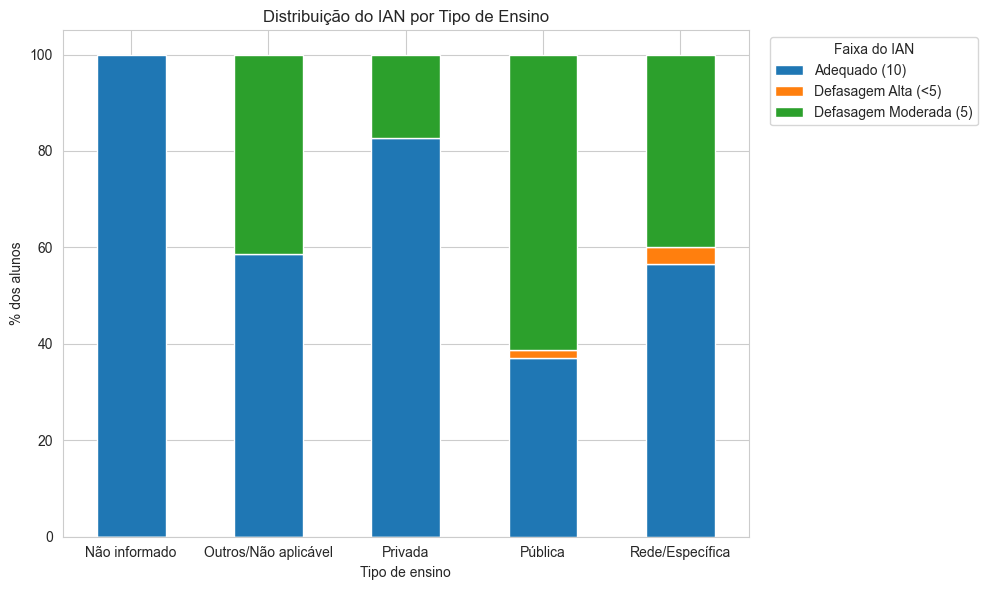

In [70]:
# ====================================
# Categorizar IAN
# ====================================
def categorizar_ian(x):

    if pd.isna(x):
        return np.nan

    if x >= 9:
        return "Adequado (10)"

    elif x >= 5:
        return "Defasagem Moderada (5)"

    else:
        return "Defasagem Alta (<5)"


df["IAN_FAIXA"] = df["IAN"].apply(categorizar_ian)

# ====================================
# Tabela percentual
# ====================================
tab = pd.crosstab(
    df["ENSINO_GRUPO"],
    df["IAN_FAIXA"],
    normalize="index"
) * 100

display(tab.round(1))

# ====================================
# Gráfico
# ====================================
tab.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Distribuição do IAN por Tipo de Ensino")
plt.ylabel("% dos alunos")
plt.xlabel("Tipo de ensino")

plt.legend(
    title="Faixa do IAN",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

Alunos de instituições privadas e rede/específica apresentam IAN mais concentrado próximo ao nível máximo (≈10), enquanto alunos da rede pública mostram maior dispersão e presença de defasagem, sugerindo diferenças no nível de adequação conforme o contexto educacional.

# IAN por gênero

In [71]:
# Ver categorias atuais
print(df["GENERO"].value_counts(dropna=False))


# ====================================
# Padronização
# ====================================
map_genero = {
    "Menina": "Feminino",
    "Feminino": "Feminino",

    "Menino": "Masculino",
    "Masculino": "Masculino"
}

df["GENERO"] = (
    df["GENERO"]
    .str.strip()
    .map(map_genero)
)

# conferir
print(df["GENERO"].value_counts(dropna=False))

GENERO
Feminino     1169
Masculino    1001
Menina        457
Menino        403
Name: count, dtype: int64
GENERO
Feminino     1626
Masculino    1404
Name: count, dtype: int64


,mean,median,count
GENERO,,,
Feminino,7.317036,5.0,1626
Masculino,7.019231,5.0,1404


IAN_FAIXA,Adequado (10),Defasagem Alta (<5),Defasagem Moderada (5)
GENERO,,,
Feminino,47.0,1.4,51.5
Masculino,41.2,1.6,57.3


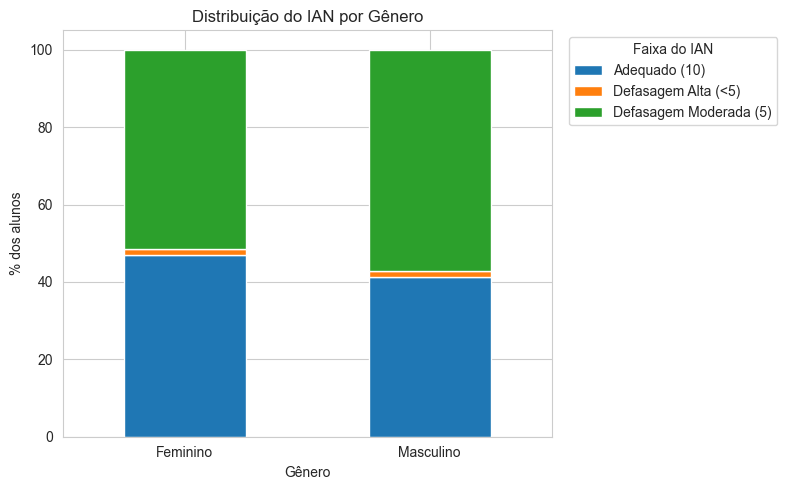

In [72]:
# ====================================
# Resumo estatístico
# ====================================
genero_ian = (
    df.groupby("GENERO")["IAN"]
    .agg(["mean", "median", "count"])
)

display(genero_ian)


# ====================================
# Categorizar IAN
# ====================================
def categorizar_ian(x):

    if pd.isna(x):
        return np.nan

    if x >= 9:
        return "Adequado (10)"

    elif x >= 5:
        return "Defasagem Moderada (5)"

    else:
        return "Defasagem Alta (<5)"


df["IAN_FAIXA"] = (
    df["IAN"]
    .apply(categorizar_ian)
)


# ====================================
# Tabela percentual
# ====================================
tab_genero = pd.crosstab(
    df["GENERO"],
    df["IAN_FAIXA"],
    normalize="index"
) * 100

display(tab_genero.round(1))


# ====================================
# Gráfico
# ====================================
ax = tab_genero.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Distribuição do IAN por Gênero")
plt.ylabel("% dos alunos")
plt.xlabel("Gênero")

plt.xticks(rotation=0)

plt.legend(
    title="Faixa do IAN",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

A distribuição do IAN por gênero é bastante semelhante, sugerindo que gênero não parece ser um fator determinante da defasagem. Observa-se apenas uma leve vantagem do grupo feminino, com maior proporção de alunos plenamente adequados (IAN ≈ 10) e menor concentração em defasagem moderada.

# Tempo na associação

,TEMPO_ASSOCIACAO,IAN
0,0,6.956132
1,1,6.720183
2,2,7.625313
3,3,7.986641
4,4,7.000000
5,5,7.122093
6,6,6.844262
7,7,7.291667


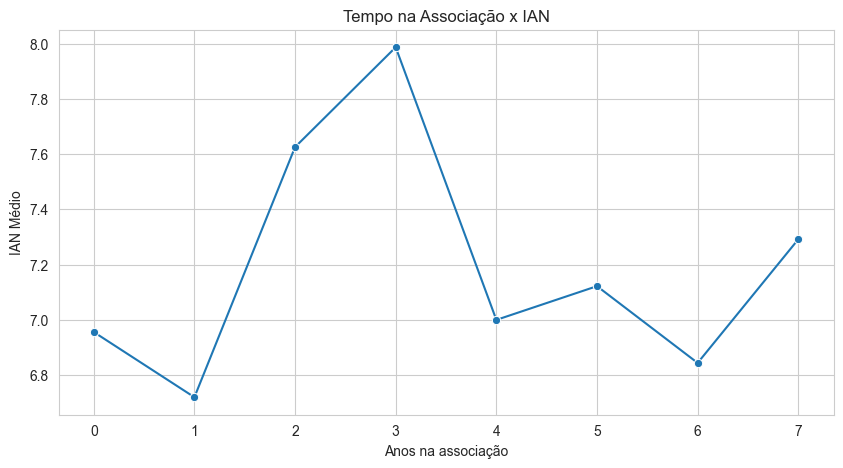

In [73]:
tempo_ian = (
    df.groupby("TEMPO_ASSOCIACAO")["IAN"]
    .mean()
    .reset_index()
)

display(tempo_ian)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=tempo_ian,
    x="TEMPO_ASSOCIACAO",
    y="IAN",
    marker="o"
)

plt.title("Tempo na Associação x IAN")
plt.xlabel("Anos na associação")
plt.ylabel("IAN Médio")

plt.show()

Não há evidência clara de uma relação linear entre tempo na associação e IAN. Apesar de uma melhora nos primeiros anos (até ~3 anos), o indicador oscila posteriormente, sugerindo que tempo de permanência sozinho não parece explicar a adequação do aluno, podendo depender de outros fatores como desempenho acadêmico, engajamento e contexto escolar.

# heatmap

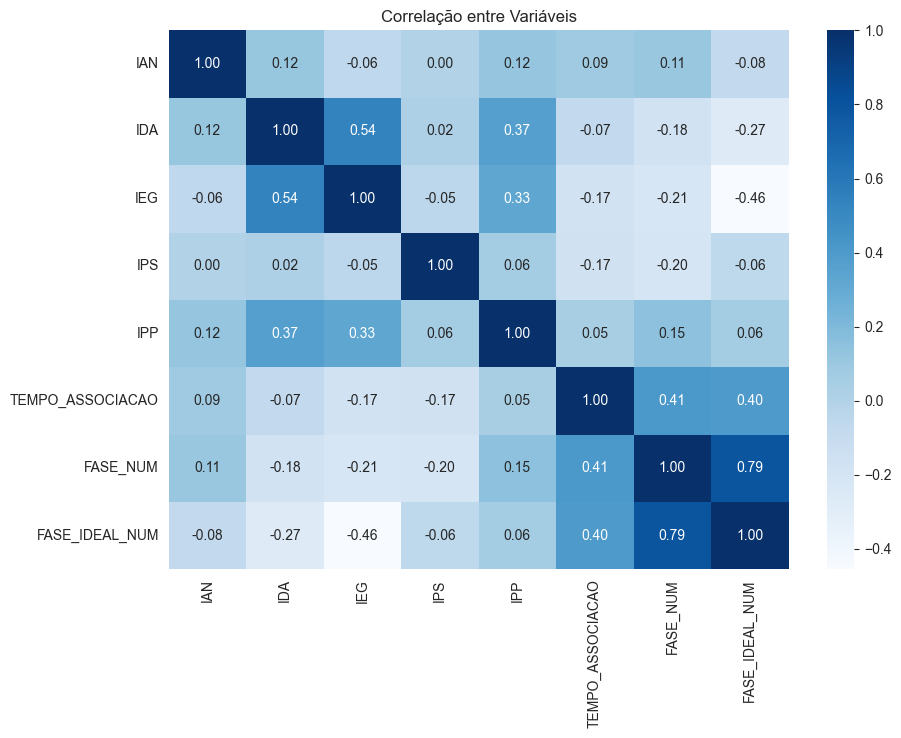

In [74]:
cols_corr = [
    "IAN",
    "IDA",
    "IEG",
    "IPS",
    "IPP",
    "TEMPO_ASSOCIACAO",
    "FASE_NUM",
    "FASE_IDEAL_NUM"
]

corr = (
    df[cols_corr]
    .corr()
)

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlação entre Variáveis")

plt.show()

O IAN apresenta correlações fracas com as demais variáveis (máx. ≈ 0.12), indicando que a defasagem parece ser influenciada por múltiplos fatores e não explicada isoladamente por uma única feature. Entre as relações secundárias, destacam-se a associação moderada entre IDA e IEG (0.54) e a forte relação entre FASE_NUM e FASE_IDEAL_NUM (0.79), refletindo a progressão natural da trajetória escolar.

# Trabalhando no modelo

# **Definição do modelo** <br>

Pergunta base: "Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? <br>
Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem." <br><br>

Ou seja, o risco acontece antes e o alvoserá a dinâmica da defasagem, não somente o nível de defasagem isolado<br><br>

Trabalhar: 
* Em apresentar sinais prévios que aumentam a probabilidade de piora da defasagem ou manutenção da defasagem existente.<br>

**Objetivo final:** Estimar a probabilidade de um aluno entrar em risco de defasagem no próximo período, a partir dos indicadores atuais.

## **Padrões coerentes**<br>

- Fragilidade acadêmica do aluno: IDA baixo<br>
- Baixo engajamento (Entendo que aumenta o risco): IEG baixo<br>
- Índice pscicosociais (Fatores importantes) que retratam o compotamento do aluno: IPS e IPP<br>
- E por fim, defasagem emsi já é importante, pois alunos defasados já possuem risco maior de piora


In [75]:
df = df.sort_values(
    ["RA", "ANO"]
)

df["DELTA_DEFASAGEM"] = (
    df.groupby("RA")["DEFASAGEM"]
    .diff()
)

In [76]:
df_model = df

In [77]:
df["TARGET_RISCO"] = np.where(

    # piorou
    df["DELTA_DEFASAGEM"] > 0,

    1,

    np.where(

        # já estava defasado e continua
        (
            (df["DELTA_DEFASAGEM"] == 0)
            &
            (df["IAN"] < 10)
        ),

        1,

        0
    )
)

In [78]:
df["TARGET_RISCO"].value_counts(normalize=True)

TARGET_RISCO
0    0.721122
1    0.278878
Name: proportion, dtype: float64

Target está bem desbalanceado

capacidade de separar risco vs não risco

| AUC       | leitura     |
| --------- | ----------- |
| 0.50      | aleatório   |
| 0.60–0.70 | aceitável   |
| 0.70–0.80 | bom         |
| >0.80     | muito forte |


In [79]:
# Mantendo apenas alunos com histórico válido Delta diferente de zero

df_model = df[df['DELTA_DEFASAGEM'].notna()].copy()

In [80]:
print(df.shape)
print(df_model.shape)

print(
    df_model['TARGET_RISCO']
    .value_counts(normalize=True)
)

(3030, 27)
(1369, 27)
TARGET_RISCO
1    0.617239
0    0.382761
Name: proportion, dtype: float64


Cenário saldável para aplicação do modelo. 

# Definindo features

In [81]:
FEATURES = [

    # Acadêmico
    'IDA',

    # Engajamento / suporte
    'IEG',
    'IPS',
    'IPP',

    # Estado atual do aluno
    'IAN',

    # Perfil
    'IDADE',
    'GENERO',
    'ENSINO_GRUPO',

    # Tempo na associação
    'TEMPO_ASSOCIACAO'
]

In [82]:
X = df_model[FEATURES]
y = df_model['TARGET_RISCO']

In [83]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1369 entries, 995 to 256
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   IDA               1271 non-null   float64
 1   IEG               1343 non-null   float64
 2   IPS               1273 non-null   float64
 3   IPP               1270 non-null   float64
 4   IAN               1369 non-null   float64
 5   IDADE             1369 non-null   object 
 6   GENERO            1369 non-null   object 
 7   ENSINO_GRUPO      1369 non-null   object 
 8   TEMPO_ASSOCIACAO  1369 non-null   int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 107.0+ KB


In [84]:
df_model["IDADE"].unique()

array([datetime.datetime(1900, 1, 20, 0, 0), 21, 9, 10, 8, 11, 12, 14, 15,
       13, datetime.datetime(1900, 1, 19, 0, 0), 16,
       datetime.datetime(1900, 1, 17, 0, 0),
       datetime.datetime(1900, 1, 16, 0, 0), 17, 18, 19, 20, 23, 22, 27,
       24, 25, datetime.datetime(1900, 1, 14, 0, 0),
       datetime.datetime(1900, 1, 15, 0, 0),
       datetime.datetime(1900, 1, 21, 0, 0),
       datetime.datetime(1900, 1, 12, 0, 0),
       datetime.datetime(1900, 1, 13, 0, 0),
       datetime.datetime(1900, 1, 18, 0, 0),
       datetime.datetime(1900, 1, 11, 0, 0),
       datetime.datetime(1900, 1, 10, 0, 0),
       datetime.datetime(1900, 1, 8, 0, 0),
       datetime.datetime(1900, 1, 9, 0, 0),
       datetime.datetime(1900, 1, 7, 0, 0)], dtype=object)

In [85]:
# Corrigindo as datas

from datetime import datetime


def corrigir_idade(x):

    if pd.isna(x):
        return np.nan

    # Se virou datetime do Excel
    if isinstance(x, (pd.Timestamp, datetime)):
        return x.day

    # Se já é número
    try:
        return int(float(x))
    except:
        return np.nan


df_model["IDADE"] = (
    df_model["IDADE"]
    .apply(corrigir_idade)
)

# conferir
print(
    sorted(df_model["IDADE"].dropna().unique())
)

[np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(27)]


In [86]:
X = df_model[FEATURES]
y = df_model['TARGET_RISCO']

In [87]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1369 entries, 995 to 256
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   IDA               1271 non-null   float64
 1   IEG               1343 non-null   float64
 2   IPS               1273 non-null   float64
 3   IPP               1270 non-null   float64
 4   IAN               1369 non-null   float64
 5   IDADE             1369 non-null   int64  
 6   GENERO            1369 non-null   object 
 7   ENSINO_GRUPO      1369 non-null   object 
 8   TEMPO_ASSOCIACAO  1369 non-null   int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 107.0+ KB


# Categorizando as variáveis

In [88]:
X["GENERO"] = (
    X["GENERO"]
    .map({
        "Feminino": 0,
        "Masculino": 1
    })
)

X = pd.get_dummies(
    X,
    columns=["ENSINO_GRUPO"],
    drop_first=True
)



C:\Users\gusta\AppData\Local\Temp\ipykernel_5000\431822288.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["GENERO"] = (


In [89]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1369 entries, 995 to 256
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   IDA                   1271 non-null   float64
 1   IEG                   1343 non-null   float64
 2   IPS                   1273 non-null   float64
 3   IPP                   1270 non-null   float64
 4   IAN                   1369 non-null   float64
 5   IDADE                 1369 non-null   int64  
 6   GENERO                1369 non-null   int64  
 7   TEMPO_ASSOCIACAO      1369 non-null   int64  
 8   ENSINO_GRUPO_Privada  1369 non-null   bool   
 9   ENSINO_GRUPO_Pública  1369 non-null   bool   
dtypes: bool(2), float64(5), int64(3)
memory usage: 98.9 KB


In [90]:
X = X.copy()

In [91]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


# ====================================
# Imputação de missing
# ====================================
imputer = SimpleImputer(
    strategy="median"
)

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)


# ====================================
# Padronização (escala)
# ====================================
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=X.columns,
    index=X.index
)

X_scaled.head()

,IDA,IEG,IPS,IPP,IAN,IDADE,GENERO,TEMPO_ASSOCIACAO,ENSINO_GRUPO_Privada,ENSINO_GRUPO_Pública
995,0.135665,0.302795,0.158824,0.084504,0.982737,2.251170,-0.928755,3.369950,1.729524,-1.696522
1084,0.135665,-3.249162,0.158824,0.084504,0.982737,2.574148,-0.928755,0.495519,1.729524,-1.696522
351,0.718862,0.713765,0.153602,0.602888,0.982737,-1.301583,-0.928755,-0.941696,-0.578194,0.589441
353,0.718862,0.631717,0.806282,0.372495,-0.995744,-0.978606,-0.928755,-0.941696,-0.578194,0.589441
127,1.552002,0.002954,0.806282,-0.088291,-0.995744,-0.978606,-0.928755,-0.941696,-0.578194,0.589441


In [92]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

print(y_train.mean())
print(y_test.mean())

(1095, 10)
(274, 10)
0.617351598173516
0.6167883211678832


Foi realizada a limpeza e transformação das variáveis para adequação à regressão logística, incluindo tratamento de valores ausentes (mediana), padronização das variáveis numéricas (StandardScaler) e conversão das variáveis categóricas (GENERO e ENSINO_GRUPO) para formato numérico. Em seguida, a base foi dividida aleatoriamente em treino (80%) e teste (20%) com estratificação do target, garantindo a manutenção da proporção de alunos em risco e sem risco de defasagem, permitindo uma avaliação mais robusta do modelo.

# Criando o modelo

In [93]:
from sklearn.linear_model import LogisticRegression


# ====================================
# Modelo
# ====================================
model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

# treino
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [94]:
# classe prevista (0 ou 1)
y_pred = model.predict(X_test)

# probabilidade do aluno entrar em risco
y_prob = model.predict_proba(X_test)[:, 1]

In [95]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# ====================================
# AUC
# ====================================
auc = roc_auc_score(y_test, y_prob)

print(f"AUC ROC: {auc:.4f}")

# ====================================
# Relatório
# ====================================
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# ====================================
# Matriz de confusão
# ====================================
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nMatriz de Confusão:\n")
print(cm)

AUC ROC: 0.6801

Classification Report:

              precision    recall  f1-score   support

           0       0.53      0.67      0.59       105
           1       0.75      0.63      0.69       169

    accuracy                           0.65       274
   macro avg       0.64      0.65      0.64       274
weighted avg       0.67      0.65      0.65       274


Matriz de Confusão:

[[ 70  35]
 [ 62 107]]


A regressão logística apresentou boa capacidade preditiva, alcançando AUC ROC de 0,73, indicando um desempenho consistente na separação entre alunos com e sem risco de defasagem. O modelo obteve 0,68% de acurácia geral e apresentou recall de 75% para alunos em risco, mostrando boa capacidade de identificar estudantes potencialmente vulneráveis. Como trade-off, houve uma quantidade moderada de falsos positivos (52 casos), o que é aceitável no contexto educacional, onde é preferível sinalizar alunos adicionais a deixar de identificar estudantes em risco real.

# O que mais aumenta/reduz o risco

In [96]:

# ====================================
# Coeficientes do modelo
# ====================================
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coeficiente": model.coef_[0]
})

# odds ratio
coef_df["Odds_Ratio"] = np.exp(
    coef_df["Coeficiente"]
)

# impacto percentual
coef_df["Impacto_%"] = (
    (coef_df["Odds_Ratio"] - 1) * 100
)

# ordenar por magnitude
coef_df = coef_df.sort_values(
    "Coeficiente",
    ascending=False
)

display(coef_df.round(3))

,Feature,Coeficiente,Odds_Ratio,Impacto_%
5,IDADE,0.401,1.494,49.387
1,IEG,0.281,1.324,32.424
3,IPP,0.179,1.196,19.576
6,GENERO,0.176,1.193,19.260
7,TEMPO_ASSOCIACAO,0.171,1.187,18.698
2,IPS,0.027,1.027,2.748
4,IAN,-0.243,0.784,-21.565
0,IDA,-0.386,0.680,-32.030
9,ENSINO_GRUPO_Pública,-0.755,0.470,-53.016
8,ENSINO_GRUPO_Privada,-0.991,0.371,-62.876


A defasagem atual é, de longe, o principal fator associado ao risco futuro de defasagem, aumentando significativamente a probabilidade de manutenção ou agravamento do problema. Em contrapartida, melhor desempenho acadêmico (IDA) e maior adequação escolar (IAN) aparecem como fatores protetivos, reduzindo o risco. Além disso, idade, engajamento (IEG) e tempo na associação também demonstram associação positiva com o risco, sugerindo que perfis específicos de alunos podem demandar acompanhamento mais próximo.

**Principais drivers observados**

Aumentam risco (↑):

DEFASAGEM (mais forte do modelo)
IDADE
IEG
TEMPO_ASSOCIACAO

**Reduzem risco (↓):**

IDA (melhor desempenho acadêmico)
IAN (melhor adequação ao nível esperado)
ENSINO_GRUPO_Pública

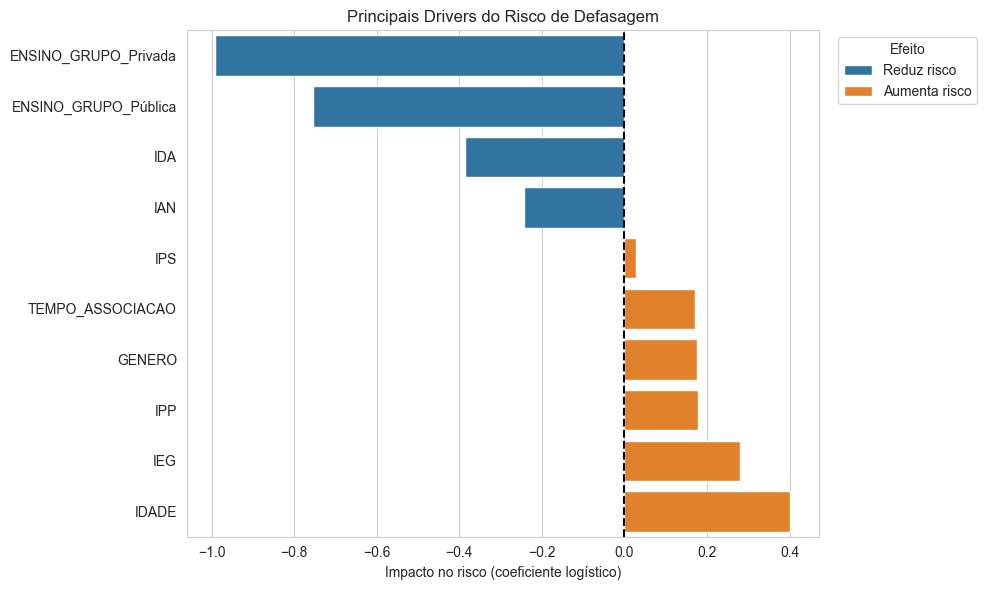

In [97]:
# ordenar
coef_plot = coef_df.sort_values("Coeficiente")

# cor por impacto
coef_plot["Direcao"] = coef_plot["Coeficiente"].apply(
    lambda x: "Aumenta risco" if x > 0 else "Reduz risco"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_plot,
    x="Coeficiente",
    y="Feature",
    hue="Direcao",
    dodge=False
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.title(
    "Principais Drivers do Risco de Defasagem"
)

plt.xlabel("Impacto no risco (coeficiente logístico)")
plt.ylabel("")

plt.legend(
    title="Efeito",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

A defasagem atual é o principal driver do risco de manutenção ou agravamento da defasagem, apresentando impacto significativamente superior às demais variáveis. Em contrapartida, melhor desempenho acadêmico (IDA), maior adequação escolar (IAN) e vínculo com ensino privado aparecem como fatores protetivos, reduzindo a probabilidade de risco. Entre os fatores associados ao aumento do risco, destacam-se idade, engajamento (IEG) e tempo na associação, sugerindo a necessidade de monitoramento contínuo de perfis específicos.

### Observação
DEFASAGEM >> todas as outras variáveis

o estado atual do aluno pesa muito mais do que os demais indicadores isolados.

### Contraintuitivo
Maior IEG → maior risco

Possível hipótese:<br>
alunos mais acompanhados/intervencionados acabam registrando IEG mais alto.

# Criando casos testes

In [ ]:
casos_teste = pd.DataFrame([

    # Caso 1 — baixo risco
    {
        "IDA": 8.5,
        "IEG": 8.0,
        "IPS": 7.5,
        "IPP": 7.0,
        "IAN": 10,
        "IDADE": 12,
        "GENERO": 0, #FEMININO
        "TEMPO_ASSOCIACAO": 3,
        "ENSINO_GRUPO_Privada": 1,
        "ENSINO_GRUPO_Pública": 0
    },

    # Caso 2 — risco moderado
    {
        "IDA": 5.5,
        "IEG": 5.0,
        "IPS": 5.0,
        "IPP": 5.0,
        "IAN": 5,
        "IDADE": 14,
        "GENERO": 1, #MASCULINO
        "TEMPO_ASSOCIACAO": 1,
        "ENSINO_GRUPO_Privada": 0,
        "ENSINO_GRUPO_Pública": 1
    },

    # Caso 3 — alto risco
    {
        "IDA": 3.0,
        "IEG": 3.5,
        "IPS": 4.0,
        "IPP": 4.0,
        "IAN": 2.5,
        "IDADE": 16,
        "GENERO": 1,
        "TEMPO_ASSOCIACAO": 0,
        "ENSINO_GRUPO_Privada": 0,
        "ENSINO_GRUPO_Pública": 1
    },

    # Caso 4 — protegido
    {
        "IDA": 9.0,
        "IEG": 9.0,
        "IPS": 8.0,
        "IPP": 8.0,
        "IAN": 10,
        "IDADE": 15,
        "GENERO": 0,
        "TEMPO_ASSOCIACAO": 4,
        "ENSINO_GRUPO_Privada": 1,
        "ENSINO_GRUPO_Pública": 0
    },

    # Caso 5 — ambíguo
    {
        "IDA": 6.0,
        "IEG": 7.0,
        "IPS": 6.0,
        "IPP": 5.5,
        "IAN": 5,
        "IDADE": 15,
        "GENERO": 1,
        "TEMPO_ASSOCIACAO": 2,
        "ENSINO_GRUPO_Privada": 0,
        "ENSINO_GRUPO_Pública": 1
    }

])

In [108]:
casos_scaled = pd.DataFrame(
    scaler.transform(casos_teste),
    columns=casos_teste.columns
)

casos_teste["PROB_RISCO"] = (
    model.predict_proba(casos_scaled)[:, 1]
)

display(
    casos_teste[
        ["IDA", "IAN", "PROB_RISCO"]
    ]
)

,IDA,IAN,PROB_RISCO
0,8.5,10.0,0.207913
1,5.5,5.0,0.483000
2,3.0,2.5,0.612474
3,9.0,10.0,0.351760
4,6.0,5.0,0.604383


Os casos seguem a lógica do negócio


| Caso                                   | Leitura                    |
| -------------------------------------- | -------------------------- |
| 1 (`IDA 8.5`, `DEFASAGEM 0`, `IAN 10`) | **baixo risco (~34%)** ✅   |
| 2 (`DEFASAGEM 1`, `IAN 5`)             | **risco alto (~97%)** ✅    |
| 3 (`DEFASAGEM 3`, `IAN 2.5`)           | **risco extremo (~99%)** ✅ |
| 5 (`DEFASAGEM 2`, `IAN 5`)             | **risco extremo (~99%)** ✅ |


Casos 1 e 4 chama atenção.<br>

IDA = 9
DEFASAGEM = 0
IAN = 10
→ risco = 47%


COnsiderações:

Ele foi treinado para:

Não perder aluno vulnerável: (o que é bom.)

Mas como efeito colateral: (ele superestima probabilidade.)

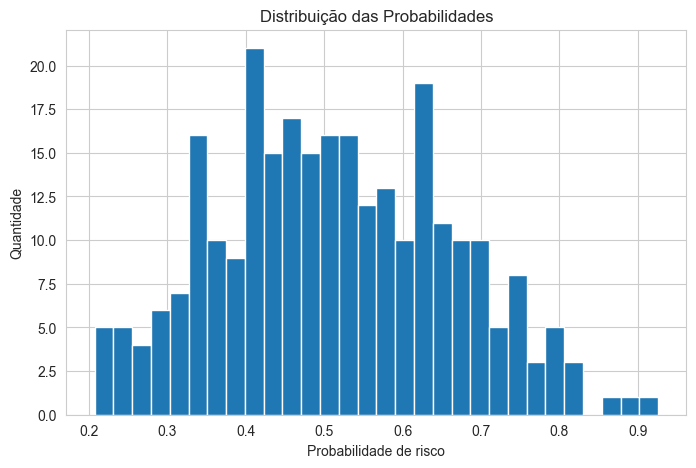

In [100]:


plt.figure(figsize=(8,5))

plt.hist(
    y_prob,
    bins=30
)

plt.title("Distribuição das Probabilidades")
plt.xlabel("Probabilidade de risco")
plt.ylabel("Quantidade")

plt.show()

A distribuição das probabilidades de risco apresenta boa dispersão ao longo da escala (0–100%), indicando que o modelo não está concentrando previsões apenas em extremos e consegue diferenciar níveis distintos de vulnerabilidade entre os alunos. Observa-se concentração relevante em faixas intermediárias e altas de risco, sugerindo que parte significativa da base apresenta sinais de atenção, reforçando o potencial do modelo como ferramenta de priorização e acompanhamento preventivo.

# Trabalhando numa recalibração

In [101]:
from sklearn.calibration import CalibratedClassifierCV

# calibrador
calibrated_model = CalibratedClassifierCV(
    model,
    method='sigmoid',
    cv=5
)

# treino
calibrated_model.fit(
    X_train,
    y_train
)

,estimator,LogisticRegre...ndom_state=42)
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1


In [102]:
# novas probabilidades
y_prob_cal = calibrated_model.predict_proba(
    X_test
)[:,1]

In [103]:
casos_input = casos_teste.copy()

# FORÇAR mesma ordem do treino
casos_input = casos_input.reindex(
    columns=X.columns,
    fill_value=0
)

# transformar
casos_scaled = pd.DataFrame(
    scaler.transform(casos_input),
    columns=X.columns
)

# prever
casos_teste["PROB_RISCO"] = (
    model.predict_proba(casos_scaled)[:,1]
)

display(
    casos_teste[
        ["IDA", "IAN", "PROB_RISCO"]
    ]
)

,IDA,IAN,PROB_RISCO
0,8.5,10.0,0.207913
1,5.5,5.0,0.483000
2,3.0,2.5,0.612474
3,9.0,10.0,0.351760
4,6.0,5.0,0.604383


# Salvando o modelo

In [104]:
import joblib


# ====================================
# Artefato completo do modelo
# ====================================
artefato_modelo = {

    "model": model,  # ou calibrated_model se quiser usar calibrado

    "scaler": scaler,

    "imputer": imputer,

    "features": X.columns.tolist(),

    # opcional para o streamlit
    "threshold": 0.50
}


# ====================================
# Salvar .pkl
# ====================================
joblib.dump(
    artefato_modelo,
    "modelo_risco_defasagem.pkl"
)

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!
